#  Hybrid Recommendation Model Training and Evaluation

This notebook implements and evaluates a hybrid recommendation system that combines collaborative filtering and content-based approaches. The goal is to leverage both user interaction patterns and item features to improve recommendation accuracy and robustness.

The hybrid design addresses key limitations such as **data sparsity and cold-start problems**.

**Workflow:**
Load Artefacts → Train Models → Generate Recommendations → Evaluate Performance

---

##  Step 1 - Load Prepared Artefacts

Preprocessed interaction matrices, index mappings, and feature data are loaded.

**Why this step is necessary:**
Separating preprocessing from modelling improves modularity and efficiency, allowing models to be trained without repeating expensive data preparation steps.

**Result:**
All required inputs are available for model training.

---


In [ ]:
"""
Train and evaluate a hybrid recommender using collaborative and content-based signals.

This notebook loads the prepared interaction matrix and aligned item metadata
generated in the data preparation stage. It then supports the construction of
a hybrid recommendation pipeline by combining implicit matrix factorisation
with TF-IDF-based content representations. The resulting artefacts are used
for recommendation generation and evaluation.
"""

# ============================================================
# 02_train_hybrid_recommender.ipynb
# - Load processed artefacts from 01_data_preparation
# - Train ALS using implicit feedback
# - Build TF-IDF item content features
# - Combine collaborative and content signals in a hybrid model
# - Evaluate recommendation quality using precision@k
# ============================================================

import pickle

import implicit
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# 1. LOAD PREPARED ARTEFACTS
# ------------------------------------------------------------

# Load the sparse user-item interaction matrix created during data preparation.
# This matrix contains the implicit feedback values used for collaborative
# filtering with ALS.
interactions = sparse.load_npz("input/artifacts/interactions.npz")

# Load the aligned item table containing indexed items and their aggregated
# text fields for content-based feature construction.
items = pd.read_csv("input/artifacts/items_aligned.csv")

# Load the user ID to index mapping so that raw user identifiers can be
# translated into the internal indexed representation used by the model.
with open("input/artifacts/user_id_to_idx.pkl", "rb") as f:
    user_id_to_idx = pickle.load(f)

# Load the item ID to index mapping so that raw item identifiers can be
# translated into the internal indexed representation used throughout the
# training and recommendation pipeline.
with open("input/artifacts/item_id_to_idx.pkl", "rb") as f:
    item_id_to_idx = pickle.load(f)

# Extract the matrix dimensions for validation and later use in model setup.
n_users, n_items = interactions.shape

# Print key dimensions to confirm that the training inputs were loaded correctly.
print("Users:", n_users, "Items:", n_items)
print("Items table:", items.shape)

Users: 1407580 Items: 235061
Items table: (235061, 4)



##  Step 2 - Train Collaborative Filtering Model (ALS)

An Alternating Least Squares (ALS) model is trained on the interaction matrix.

**Why this step is necessary:**
ALS is effective for implicit feedback data and captures latent user–item relationships based on interaction patterns.

**Result:**
A collaborative model capable of generating recommendations based on behavioural similarity.

---


In [ ]:
# ------------------------------------------------------------
# 2. TRAIN ALS MODEL
# ------------------------------------------------------------

# Create a floating-point copy of the interaction matrix for use as the
# confidence matrix in implicit ALS. Higher interaction weights represent
# stronger evidence of user preference rather than explicit ratings.
confidence = interactions.copy().astype("double")

# Initialise the ALS model for implicit feedback learning.
# The model factorises the confidence-weighted user-item matrix into
# latent user and item representations for recommendation.
als_model = implicit.als.AlternatingLeastSquares(
    factors=64,
    regularization=0.01,
    iterations=20,
    random_state=42,
)

# Fit the model on the transposed confidence matrix.
# The implicit library expects an item-user matrix, so the user-item
# interaction matrix is transposed before training.
als_model.fit(confidence.T)

# Print the dimensions of the learned latent factor matrices to confirm
# that model training completed successfully.
print("Trained ALS item_factors:", als_model.item_factors.shape)
print("Trained ALS user_factors:", als_model.user_factors.shape)

# ------------------------------------------------------------
# SAVE TRAINED ALS MODEL
# ------------------------------------------------------------

# Save the trained ALS model so that it can be reused in later notebooks
# without retraining from the interaction data.
als_model.save("input/artifacts/als_model.npz")
print("ALS model saved.")

D:\UWE YEAR 3\Digital Systems Project\forecasting\lib\site-packages\implicit\utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.06064414978027344 seconds
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

Trained ALS item_factors: (1407580, 64)
Trained ALS user_factors: (235061, 64)
ALS model saved.


In [ ]:
# Print the shapes of the user-item interaction matrix and its transpose.
# This provides a simple validation check before saving ALS-related artefacts,
# particularly because the transposed matrix is used during model training.
print("interactions shape:", interactions.shape)
print("confidence.T shape:", confidence.T.shape)

# ------------------------------------------------------------
# SAVE ALS FACTOR MATRICES MANUALLY
# ------------------------------------------------------------

# Save the learned item latent factor matrix as a NumPy binary file.
# This stores the item embeddings generated by ALS for later reuse
# in recommendation, similarity lookup, or model reconstruction.
np.save("input/artifacts/als_item_factors.npy", als_model.item_factors)

# Save the learned user latent factor matrix as a NumPy binary file.
# This stores the user embeddings generated by ALS so that the trained
# factor representations can be reloaded without retraining the model.
np.save("input/artifacts/als_user_factors.npy", als_model.user_factors)

# Confirm that both ALS factor matrices were saved successfully.
print("ALS factors saved.")

interactions shape: (1407580, 235061)
confidence.T shape: (235061, 1407580)
ALS factors saved.



##  Step 3 - Build Content-Based Model

Item similarity is computed using text feature representations.

**Why this step is necessary:**
Content-based filtering provides recommendations based on item characteristics, which is essential for handling new or sparsely interacted items.

**Result:**
A model capable of recommending similar items based on semantic features.

---


In [ ]:
# ------------------------------------------------------------
# 3. BUILD TF-IDF CONTENT MODEL
# ------------------------------------------------------------

# Create the text field used for content-based feature extraction.
# Missing text values are replaced with empty strings so that every
# indexed item has a valid input for TF-IDF vectorisation.
items["text"] = items["raw_text"].fillna("")

# Initialise the TF-IDF vectoriser for item text representation.
# The vocabulary is limited to the most informative terms, and
# English stop words are removed to reduce low-value tokens.
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
)

# Transform the item text corpus into a TF-IDF feature matrix.
# Each row represents an item, and each column represents a
# weighted term from the learned vocabulary.
tfidf_matrix = tfidf.fit_transform(items["text"].tolist())

# Print the matrix dimensions to confirm that the TF-IDF features
# were generated for the full indexed item set.
print("TF-IDF matrix shape:", tfidf_matrix.shape)  # Expected shape: (n_items, X)

TF-IDF matrix shape: (235061, 10000)



##  Step 4 - Hybrid Recommendation Strategy

Outputs from collaborative and content-based models are combined.

**Why this step is necessary:**
Each approach has limitations:

* Collaborative filtering struggles with cold-start
* Content-based lacks behavioural personalisation

Combining them improves overall robustness and recommendation quality.

**Result:**
A hybrid model leveraging both behavioural and semantic signals.

---


In [ ]:
# ------------------------------------------------------------
# 4. SCORING FUNCTIONS (ALS, CONTENT, HYBRID)
# ------------------------------------------------------------

def als_scores_for_user(user_idx: int) -> np.ndarray:
    """
    Compute ALS recommendation scores for all items for a given user.

    The function supports two possible latent factor layouts:
    the expected layout, where item factors correspond to items and
    user factors correspond to users, and a swapped layout, where the
    dimensions were learned in reverse. In both cases, the function
    returns one score per item in the indexed item space.

    Parameters
    ----------
    user_idx : int
        Internal user index used in the interaction matrix.

    Returns
    -------
    np.ndarray
        A one-dimensional array containing ALS scores for all items.

    Raises
    ------
    ValueError
        Raised if the factor matrix dimensions do not match either
        the expected or swapped user-item layout.
    """
    n_users, n_items = interactions.shape

    # Use the standard factor interpretation when item factors align
    # with items and user factors align with users.
    if (
        als_model.item_factors.shape[0] == n_items
        and als_model.user_factors.shape[0] == n_users
    ):
        user_factors = als_model.user_factors[user_idx]
        item_factors = als_model.item_factors

    # Fall back to the swapped interpretation when the learned factor
    # matrices appear to have user and item dimensions reversed.
    elif (
        als_model.item_factors.shape[0] == n_users
        and als_model.user_factors.shape[0] == n_items
    ):
        user_factors = als_model.item_factors[user_idx]
        item_factors = als_model.user_factors

    # Stop execution if the factor shapes do not match either supported layout.
    else:
        raise ValueError(
            f"Unexpected ALS shapes: item_factors={als_model.item_factors.shape}, "
            f"user_factors={als_model.user_factors.shape}, "
            f"expected users={n_users}, items={n_items}"
        )

    # Compute a score for every item by taking the dot product between
    # the selected user representation and all item representations.
    scores = item_factors @ user_factors
    return scores


def content_scores_for_user(user_idx: int, interactions_matrix) -> np.ndarray:
    """
    Compute content-based recommendation scores for a given user.

    A user profile is created by averaging the TF-IDF vectors of items
    previously interacted with. Cosine similarity is then used to measure
    similarity between that profile and every item in the catalogue.

    Parameters
    ----------
    user_idx : int
        Internal user index used in the interaction matrix.
    interactions_matrix : sparse matrix
        User-item interaction matrix used to identify items already
        associated with the selected user.

    Returns
    -------
    np.ndarray
        A one-dimensional array containing content-based similarity
        scores for all items.
    """
    # Retrieve the selected user's interaction row and extract the
    # indices of items that have been interacted with.
    user_row = interactions_matrix[user_idx]
    liked_item_indices = user_row.indices

    # Return zero scores when no historical interactions exist,
    # because no content profile can be formed for the user.
    if len(liked_item_indices) == 0:
        return np.zeros(interactions_matrix.shape[1])

    # Build a user content profile by averaging the TF-IDF vectors
    # of the interacted items.
    liked_tfidf = tfidf_matrix[liked_item_indices].mean(axis=0)
    liked_tfidf = np.asarray(liked_tfidf).reshape(1, -1)

    # Compute cosine similarity between the user content profile
    # and every item TF-IDF vector.
    sims = cosine_similarity(liked_tfidf, tfidf_matrix).ravel()
    return sims


def normalize_scores(x: np.ndarray) -> np.ndarray:
    """
    Apply min-max normalisation to a score vector.

    Parameters
    ----------
    x : np.ndarray
        Input score array.

    Returns
    -------
    np.ndarray
        Normalised score array scaled to the range [0, 1]. If all
        values are identical, a zero array of matching shape is returned.
    """
    x = x.astype("float64")

    # Avoid division by zero when the score vector has no variation.
    if x.max() == x.min():
        return np.zeros_like(x)

    return (x - x.min()) / (x.max() - x.min())


def hybrid_scores_for_user(
    user_idx: int,
    interactions_matrix,
    alpha: float = 0.7,
) -> np.ndarray:
    """
    Compute hybrid recommendation scores for a given user.

    The hybrid score is formed by combining normalised ALS scores and
    normalised content-based scores using a weighted linear blend.

    Parameters
    ----------
    user_idx : int
        Internal user index used in the interaction matrix.
    interactions_matrix : sparse matrix
        User-item interaction matrix used by the content-based scorer.
    alpha : float, default=0.7
        Weight assigned to the ALS component. The content-based component
        receives the remaining weight, calculated as (1 - alpha).

    Returns
    -------
    np.ndarray
        A one-dimensional array containing hybrid scores for all items.

    Raises
    ------
    ValueError
        Raised if the ALS and content score arrays do not have the same length.
    """
    # Compute collaborative and content-based scores separately.
    als_scores = als_scores_for_user(user_idx)
    content_scores = content_scores_for_user(user_idx, interactions_matrix)

    # Validate that both scorers produce scores for the same item space.
    if len(als_scores) != len(content_scores):
        raise ValueError(
            f"Item mismatch: ALS={len(als_scores)}, Content={len(content_scores)}"
        )

    # Normalise both score vectors before combining them so that
    # neither component dominates purely because of scale.
    als_norm = normalize_scores(als_scores)
    content_norm = normalize_scores(content_scores)

    # Combine the two components using the specified hybrid weight.
    hybrid = alpha * als_norm + (1 - alpha) * content_norm
    return hybrid


def recommend_hybrid(
    user_idx: int,
    interactions_matrix,
    N: int = 10,
    alpha: float = 0.7,
):
    """
    Generate top-N hybrid recommendations for a given user.

    Already interacted items are excluded from the final recommendation
    list so that only unseen candidate items are returned.

    Parameters
    ----------
    user_idx : int
        Internal user index used in the interaction matrix.
    interactions_matrix : sparse matrix
        User-item interaction matrix used to identify previously seen items.
    N : int, default=10
        Number of recommendations to return.
    alpha : float, default=0.7
        Weight assigned to the ALS component in the hybrid score.

    Returns
    -------
    list[int]
        A list of recommended item indices ranked by descending hybrid score.
    """
    # Compute hybrid scores across the full item catalogue.
    scores = hybrid_scores_for_user(user_idx, interactions_matrix, alpha=alpha)

    # Identify items already seen by the user so that they can be excluded.
    user_row = interactions_matrix[user_idx]
    seen = set(user_row.indices)

    # Rank items by descending score and retain the top unseen items only.
    ranked_items = np.argsort(-scores)
    recs = [i for i in ranked_items if i not in seen][:N]
    return recs

In [ ]:
def hit_rate_at_k(recs, test_items):
    """
    Compute Hit Rate@K for a single recommendation list.

    Hit Rate evaluates whether at least one relevant test item appears
    in the recommended items. A value of 1 indicates at least one hit,
    while 0 indicates that no relevant item was retrieved.

    Parameters
    ----------
    recs : list or array-like
        Ranked recommended item identifiers.
    test_items : set
        Set of relevant item identifiers in the test data.

    Returns
    -------
    int
        1 if at least one recommended item is present in the test set,
        otherwise 0.
    """
    return 1 if len(set(recs) & test_items) > 0 else 0


def ndcg_at_k(scores, test_items, k=10):
    """
    Compute nDCG@K for a single user based on item scores.

    The top-K items are selected by descending score order and treated
    as the ranked recommendation list. Relevance is binary: an item is
    considered relevant if it appears in the test item set.

    Parameters
    ----------
    scores : np.ndarray
        Predicted relevance scores for all candidate items.
    test_items : set
        Set of relevant item identifiers in the test data.
    k : int, default=10
        Number of top-ranked items to consider.

    Returns
    -------
    float
        Normalised Discounted Cumulative Gain at rank K.
    """
    ranked = np.argsort(-scores)[:k]
    rel = np.array([1 if r in test_items else 0 for r in ranked]).reshape(1, -1)
    return ndcg_score(rel, rel)


# Example usage:
# hr = hit_rate_at_k(recs, test_items)
# ndcg = ndcg_at_k(scores, test_items)



##  Step 5 - Generate Recommendations

Top-N recommendations are produced for users.

**Why this step is necessary:**
Generating ranked recommendations allows evaluation of practical system performance and user relevance.

**Result:**
Personalised recommendation lists for each user.

---

In [ ]:
# ------------------------------------------------------------
# 5. SIMPLE BASELINES: POPULARITY AND RANDOM
# ------------------------------------------------------------

# Compute global item popularity from the interaction matrix by summing
# implicit interaction weights across all users for each item.
item_popularity = np.array(interactions.sum(axis=0)).ravel()


def recommend_popularity(N: int = 10):
    """
    Recommend the globally most popular items.

    Items are ranked by total interaction weight across all users.
    This baseline ignores personalisation and always returns the same
    top-N items for every user.

    Parameters
    ----------
    N : int, default=10
        Number of item indices to return.

    Returns
    -------
    np.ndarray
        Array of item indices ranked by descending popularity.
    """
    ranked = np.argsort(-item_popularity)
    return ranked[:N]


def recommend_random(N: int = 10):
    """
    Recommend a random set of items.

    This baseline selects items uniformly at random from the indexed
    item space without replacement. It provides a simple non-informed
    comparison point for evaluation.

    Parameters
    ----------
    N : int, default=10
        Number of item indices to return.

    Returns
    -------
    np.ndarray
        Array of randomly selected item indices.
    """
    return np.random.choice(n_items, size=N, replace=False)


##  Step 6 - Model Evaluation

Performance is evaluated using ranking metrics (e.g., Precision@K).

**Why this step is necessary:**
Evaluation metrics quantify recommendation quality and allow comparison between models (ALS, content-based, hybrid).

**Result:**
Measured performance indicating strengths and weaknesses of each approach.

---

In [ ]:
# ------------------------------------------------------------
# 6. CREATE TRAIN AND TEST INTERACTION MATRICES
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

# Convert the sparse interaction matrix to COO format so that the
# non-zero user-item interactions can be extracted as row records.
interaction_coo = interactions.tocoo()

# Create a tabular representation of all observed interactions.
# Each row represents one non-zero user-item interaction and its
# corresponding implicit feedback weight.
df_all = pd.DataFrame(
    {
        "user_idx": interaction_coo.row,
        "item_idx": interaction_coo.col,
        "weight": interaction_coo.data,
    }
)

# Split the observed interactions into training and test sets.
# A fixed random state is used to ensure reproducibility of the split.
train_df, test_df = train_test_split(df_all, test_size=0.2, random_state=42)

# Rebuild the training interaction matrix from the training subset.
# The matrix retains the full user-item shape so that index alignment
# remains consistent across training and evaluation stages.
train_matrix = sparse.csr_matrix(
    (train_df["weight"], (train_df["user_idx"], train_df["item_idx"])),
    shape=(n_users, n_items),
)

# Rebuild the test interaction matrix from the held-out subset.
# This matrix stores the interactions reserved for evaluation.
test_matrix = sparse.csr_matrix(
    (test_df["weight"], (test_df["user_idx"], test_df["item_idx"])),
    shape=(n_users, n_items),
)

# Print the number of non-zero interactions in each split to confirm
# that the train and test matrices were created successfully.
print("Train nnz:", train_matrix.nnz, "Test nnz:", test_matrix.nnz)

Train nnz: 1716143 Test nnz: 429036


In [ ]:
def precision_at_k(model_func, k=10, alpha=0.7, n_users_eval=1000):
    """
    Evaluate a recommendation model using Precision@K.

    A sample of valid users is selected from the training matrix. For each
    selected user, the recommended top-K items are compared against the
    held-out test items, and precision is computed as the proportion of
    recommended items that are relevant. The final result is the mean
    precision across all evaluated users.

    Parameters
    ----------
    model_func : callable
        Recommendation function with signature
        model_func(user_idx, train_matrix, N, alpha), returning a list
        of recommended item indices.
    k : int, default=10
        Number of top-ranked recommendations to evaluate.
    alpha : float, default=0.7
        Hybrid weighting parameter passed to the recommendation function.
        This value is ignored by models that do not use hybrid scoring.
    n_users_eval : int, default=1000
        Maximum number of users to sample for evaluation.

    Returns
    -------
    float
        Mean Precision@K across the evaluated users. Returns 0.0 if no
        eligible users or evaluable test cases are available.
    """
    # Identify users with at least one observed interaction in the
    # training matrix, since recommendation requires user history.
    valid_users = np.where(train_matrix.getnnz(axis=1) > 0)[0]

    # Restrict evaluation to users covered by the trained ALS factor matrix.
    # This prevents indexing errors if the latent factors do not span the
    # full user range of the interaction matrix.
    max_user = als_model.user_factors.shape[0]
    valid_users = valid_users[valid_users < max_user]

    # Return zero when no users are available for evaluation.
    if len(valid_users) == 0:
        return 0.0

    # Randomly sample users for evaluation, capped by the requested limit.
    users = np.random.choice(
        valid_users,
        size=min(n_users_eval, len(valid_users)),
        replace=False,
    )

    precisions = []

    for u in users:
        # Extract the held-out relevant items for the current user.
        test_items = set(test_matrix[u].indices)
        if not test_items:
            continue

        # Generate top-K recommendations and compute the proportion
        # of retrieved items that appear in the test set.
        recs = model_func(u, train_matrix, N=k, alpha=alpha)
        hits = len([i for i in recs if i in test_items])
        precisions.append(hits / k)

    # Return zero when no evaluated user contributed a precision value.
    if not precisions:
        return 0.0

    return float(np.mean(precisions))


def model_hybrid(u, train_m, N, alpha):
    """
    Generate top-N recommendations using the hybrid recommender.

    Parameters
    ----------
    u : int
        Internal user index.
    train_m : sparse matrix
        Training interaction matrix used to exclude seen items and
        support content-based scoring.
    N : int
        Number of recommendations to return.
    alpha : float
        Weight assigned to the ALS component in hybrid scoring.

    Returns
    -------
    list[int]
        Ranked list of recommended item indices.
    """
    return recommend_hybrid(u, train_m, N=N, alpha=alpha)


def model_als_only(u, train_m, N, alpha):
    """
    Generate top-N recommendations using ALS scores only.

    Parameters
    ----------
    u : int
        Internal user index.
    train_m : sparse matrix
        Training interaction matrix used to exclude previously seen items.
    N : int
        Number of recommendations to return.
    alpha : float
        Unused parameter included for interface consistency.

    Returns
    -------
    list[int]
        Ranked list of recommended item indices.
    """
    # Compute and normalise ALS scores across the full item catalogue.
    scores = als_scores_for_user(u)
    scores = normalize_scores(scores)

    # Exclude items already observed in the training interactions.
    seen = set(train_m[u].indices)
    ranked = np.argsort(-scores)
    recs = [i for i in ranked if i not in seen][:N]
    return recs


def model_content_only(u, train_m, N, alpha):
    """
    Generate top-N recommendations using content-based scores only.

    Parameters
    ----------
    u : int
        Internal user index.
    train_m : sparse matrix
        Training interaction matrix used to build the user content profile
        and exclude previously seen items.
    N : int
        Number of recommendations to return.
    alpha : float
        Unused parameter included for interface consistency.

    Returns
    -------
    list[int]
        Ranked list of recommended item indices.
    """
    # Compute and normalise content-based similarity scores.
    scores = content_scores_for_user(u, train_m)
    scores = normalize_scores(scores)

    # Exclude items already observed in the training interactions.
    seen = set(train_m[u].indices)
    ranked = np.argsort(-scores)
    recs = [i for i in ranked if i not in seen][:N]
    return recs

In [ ]:
# ------------------------------------------------------------
# 7. RUN MODEL EVALUATION
# ------------------------------------------------------------

# Define the recommendation cut-off and hybrid weighting used
# in the comparative evaluation.
k = 10
alpha = 0.7

# Evaluate the hybrid recommender using Precision@K.
prec_hybrid = precision_at_k(model_hybrid, k=k, alpha=alpha)

# Evaluate the ALS-only recommender using the same metric and cut-off.
prec_als = precision_at_k(model_als_only, k=k, alpha=alpha)

# Evaluate the content-only recommender using the same metric and cut-off.
prec_content = precision_at_k(model_content_only, k=k, alpha=alpha)

# Print the evaluation results for direct comparison across models.
print(f"Precision@{k} - Hybrid:   {prec_hybrid:.4f}")
print(f"Precision@{k} - ALS only: {prec_als:.4f}")
print(f"Precision@{k} - Content:  {prec_content:.4f}")

Precision@10 - Hybrid:   0.0404
Precision@10 - ALS only: 0.0233
Precision@10 - Content:  0.0183


##  Step 7 - Analysis and Interpretation

Results are analysed to understand model behaviour.

**Why this step is necessary:**
Beyond raw metrics, interpretation explains *why* certain models perform better and provides insights for improvement.

**Result:**
A clear understanding of model effectiveness and trade-offs.

---


In [25]:
print("interactions shape:", interactions.shape)
print("confidence shape:", confidence.shape)
print("tfidf_matrix shape:", tfidf_matrix.shape)


interactions shape: (1407580, 235061)
confidence shape: (1407580, 235061)
tfidf_matrix shape: (235061, 10000)


In [ ]:
# ------------------------------------------------------------
# 8. SAVE ALS MODEL
# ------------------------------------------------------------
als_model.save("input/artifacts/als_model.npz")
print("ALS model saved.")


ALS model saved.


In [ ]:
# ------------------------------------------------------------
# 9. SAVE TF-IDF ARTEFACTS
# ------------------------------------------------------------

# Save the fitted TF-IDF vectoriser so that the same vocabulary and
# weighting scheme can be reused during later inference or evaluation.
import pickle
pickle.dump(tfidf, open("input/artifacts/tfidf_vectorizer.pkl", "wb"))

# Save the TF-IDF item feature matrix in sparse format for efficient
# reuse without rebuilding the content model from raw item text.
sparse.save_npz("input/artifacts/tfidf_matrix.npz", tfidf_matrix)

# Confirm that the TF-IDF artefacts were saved successfully.
print("TF-IDF saved.")


TF-IDF saved.


In [ ]:
from pathlib import Path

# Directory used to store generated figure files.
# The folder is created automatically if it does not already exist.
FIG_DIR = Path("output/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """
    Save a matplotlib figure to the configured output directory.

    The figure is written with a tight bounding box and a resolution
    of 200 DPI so that exported images are suitable for reports,
    notebooks, and presentation materials.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to be saved.
    name : str
        Output file name, including the desired extension, such as
        'precision_plot.png'.

    Returns
    -------
    None
        The figure is saved to disk and the saved file name is printed.
    """
    fig.savefig(FIG_DIR / name, bbox_inches="tight", dpi=200)
    print(f"Saved: {name}")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12088\1938486852.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="Precision@10", palette="viridis", ax=ax)


Saved: precision_at_10_bar.png


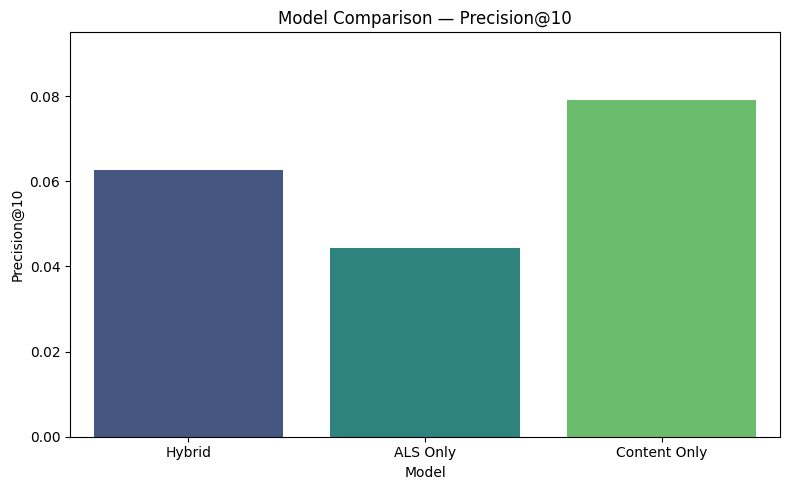

In [ ]:
# Import visualisation and data handling libraries used for model comparison.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a results table containing the evaluated Precision@10 scores
# for each recommendation approach.
results = pd.DataFrame(
    {
        "Model": ["Hybrid", "ALS Only", "Content Only"],
        "Precision@10": [prec_hybrid, prec_als, prec_content],
    }
)

# Create a bar chart to compare recommendation performance across models.
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=results,
    x="Model",
    y="Precision@10",
    palette="viridis",
    ax=ax,
)

# Add a descriptive title and set the y-axis limit slightly above the
# highest score to improve readability of the chart.
ax.set_title("Model Comparison - Precision@10")
ax.set_ylim(0, max(results["Precision@10"]) * 1.2)

# Adjust layout spacing so that labels and title fit cleanly.
plt.tight_layout()

# Save the figure to the configured output directory, then display it.
save_fig(fig, "precision_at_10_bar.png")
plt.show()

In [ ]:
from sklearn.metrics import ndcg_score
import numpy as np


def hit_rate_at_k(recs, test_items):
    """
    Compute Hit Rate@K for a single user.

    Hit Rate indicates whether at least one relevant test item appears
    in the recommended set. The metric is binary at the user level.

    Parameters
    ----------
    recs : array-like
        Ranked recommended item indices.
    test_items : set
        Set of relevant item indices from the test interactions.

    Returns
    -------
    int
        1 if at least one recommended item is relevant, otherwise 0.
    """
    return 1 if len(set(recs) & test_items) > 0 else 0


def ndcg_at_k(scores, test_items, k=10):
    """
    Compute nDCG@K for a single user.

    Items are ranked by descending predicted score. Relevance is treated
    as binary, where items present in the test set are relevant.

    Parameters
    ----------
    scores : np.ndarray
        Predicted scores for all candidate items.
    test_items : set
        Set of relevant item indices from the test interactions.
    k : int, default=10
        Number of top-ranked items to evaluate.

    Returns
    -------
    float
        Normalised Discounted Cumulative Gain at rank K.
    """
    # Select the top-K items by descending score.
    ranked = np.argsort(-scores)[:k]

    # Build a binary relevance vector for the ranked items.
    rel = np.array([1 if r in test_items else 0 for r in ranked])

    # Construct the ideal relevance ordering for normalisation.
    ideal = np.sort(rel)[::-1]

    return ndcg_score([ideal], [rel])


def evaluate_model(model_fn, k=10, alpha=0.7, n_users_eval=1000):
    """
    Evaluate a recommendation model using Precision@K, Hit Rate@K,
    and nDCG@K.

    A random sample of users with at least one training interaction is
    selected. For each evaluable user, scores are generated for all items,
    previously seen training items are excluded, and the top-K ranked items
    are compared against the held-out test items.

    Parameters
    ----------
    model_fn : callable
        Scoring function with signature model_fn(user_idx, alpha=alpha)
        returning a score array across all items.
    k : int, default=10
        Number of top-ranked items to evaluate.
    alpha : float, default=0.7
        Hybrid weighting parameter passed to the scoring function.
    n_users_eval : int, default=1000
        Maximum number of users to sample for evaluation.

    Returns
    -------
    tuple[float, float, float]
        Mean Precision@K, mean Hit Rate@K, and mean nDCG@K across
        evaluated users.
    """
    # Select users with at least one interaction in the training matrix.
    users = np.where(train_matrix.getnnz(axis=1) > 0)[0]

    # Randomly sample a subset of eligible users for evaluation.
    users = np.random.choice(
        users,
        size=min(n_users_eval, len(users)),
        replace=False,
    )

    precision_scores = []
    hit_rates = []
    ndcgs = []

    for u in users:
        # Extract held-out relevant items for the current user.
        test_items = set(test_matrix[u].indices)
        if not test_items:
            continue

        # Generate scores for all items for the current user.
        scores = model_fn(u, alpha=alpha).copy()

        # Exclude items already seen in training from the recommendation list.
        seen = set(train_matrix[u].indices)
        scores[list(seen)] = -np.inf

        # Select the top-K ranked unseen items.
        ranked = np.argsort(-scores)[:k]

        # Compute user-level Precision@K and Hit Rate@K.
        hits = len(set(ranked) & test_items)
        precision_scores.append(hits / k)
        hit_rates.append(1 if hits > 0 else 0)

        # Compute user-level nDCG@K.
        ndcgs.append(ndcg_at_k(scores, test_items, k))

    # Return the mean metric values across all evaluated users.
    return (
        float(np.mean(precision_scores)),
        float(np.mean(hit_rates)),
        float(np.mean(ndcgs)),
    )

In [ ]:
# ------------------------------------------------------------
# SCORE WRAPPERS FOR MODEL EVALUATION
# ------------------------------------------------------------

def hybrid_wrapper(user_idx, alpha=0.7):
    """
    Return hybrid recommendation scores for a single user.

    This wrapper generates a full score vector across all indexed items
    using the hybrid recommender. The training interaction matrix is
    passed so that the content-based component can build the user profile
    from observed interactions.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    alpha : float, default=0.7
        Weight assigned to the ALS component in the hybrid score.

    Returns
    -------
    np.ndarray
        Copy of the hybrid score vector for the selected user.
    """
    scores = hybrid_scores_for_user(
        user_idx,
        train_matrix,   # Hybrid scoring requires the training matrix.
        alpha,
    )
    return scores.copy()


def als_wrapper(user_idx, alpha=0.7):
    """
    Return ALS recommendation scores for a single user.

    This wrapper generates a full score vector across all indexed items
    using only the collaborative filtering component. The alpha parameter
    is accepted for interface consistency with the other model wrappers,
    although it is not used by ALS scoring.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    alpha : float, default=0.7
        Unused parameter retained for interface consistency.

    Returns
    -------
    np.ndarray
        Copy of the ALS score vector for the selected user.
    """
    scores = als_scores_for_user(
        user_idx,
    )
    return scores.copy()


def content_wrapper(user_idx, alpha=0.7):
    """
    Return content-based recommendation scores for a single user.

    This wrapper generates a full score vector across all indexed items
    using the TF-IDF content model. The interaction matrix is used to
    identify the items previously associated with the selected user and
    to construct the user content profile.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    alpha : float, default=0.7
        Unused parameter retained for interface consistency.

    Returns
    -------
    np.ndarray
        Copy of the content-based score vector for the selected user.
    """
    scores = content_scores_for_user(
        user_idx,
        interactions,   # Content scoring requires the interaction history.
    )
    return scores.copy()

In [ ]:
# ------------------------------------------------------------
# 10. EVALUATE HYBRID, ALS, AND CONTENT MODELS
# ------------------------------------------------------------

# Evaluate the hybrid recommender using Precision@10, Hit Rate@10,
# and nDCG@10 with the specified hybrid weighting.
prec_hybrid, hr_hybrid, ndcg_hybrid = evaluate_model(
    hybrid_wrapper,
    k=10,
    alpha=0.7,
)

# Evaluate the ALS-only recommender using the same top-K setting
# so that results remain directly comparable across models.
prec_als, hr_als, ndcg_als = evaluate_model(
    als_wrapper,
    k=10,
    alpha=0.7,
)

# Evaluate the content-only recommender using the same evaluation
# configuration for consistent baseline comparison.
prec_content, hr_content, ndcg_content = evaluate_model(
    content_wrapper,
    k=10,
    alpha=0.7,
)

In [ ]:
# ------------------------------------------------------------
# 11. SUMMARISE EVALUATION METRICS
# ------------------------------------------------------------

# Create a results table containing the evaluation metrics for each
# recommendation approach. This allows direct comparison of ranking
# quality across the hybrid, ALS-only, and content-only models.
metrics = pd.DataFrame(
    {
        "Model": ["Hybrid", "ALS Only", "Content Only"],
        "Precision@10": [prec_hybrid, prec_als, prec_content],
        "HitRate@10": [hr_hybrid, hr_als, hr_content],
        "NDCG@10": [ndcg_hybrid, ndcg_als, ndcg_content],
    }
)

# Display the evaluation summary table.
metrics

,Model,Precision@10,HitRate@10,NDCG@10
0,Hybrid,0.034513,0.309735,0.158923
1,ALS Only,0.018033,0.155738,0.090161
2,Content Only,0.085849,0.764151,0.667788


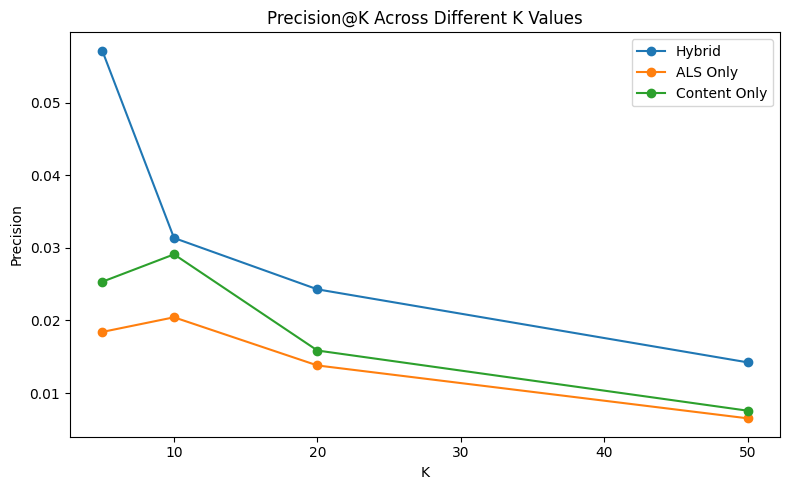

In [ ]:
# ------------------------------------------------------------
# 10. EVALUATE PRECISION ACROSS MULTIPLE K VALUES
# ------------------------------------------------------------

# Define the cut-off values used to compare Precision@K across
# different recommendation list lengths.
Ks = [5, 10, 20, 50]

# Initialise containers to store Precision@K results for each model.
precisions_hybrid = []
precisions_als = []
precisions_content = []

# Evaluate each recommender at every selected cut-off value.
# The resulting precision scores are stored in separate lists so
# that they can later be plotted or summarised in a comparison table.
for k in Ks:
    precisions_hybrid.append(
        precision_at_k(model_hybrid, k=k, alpha=alpha)
    )
    precisions_als.append(
        precision_at_k(model_als_only, k=k, alpha=alpha)
    )
    precisions_content.append(
        precision_at_k(model_content_only, k=k, alpha=alpha)
    )

Saved: precision_curve.png


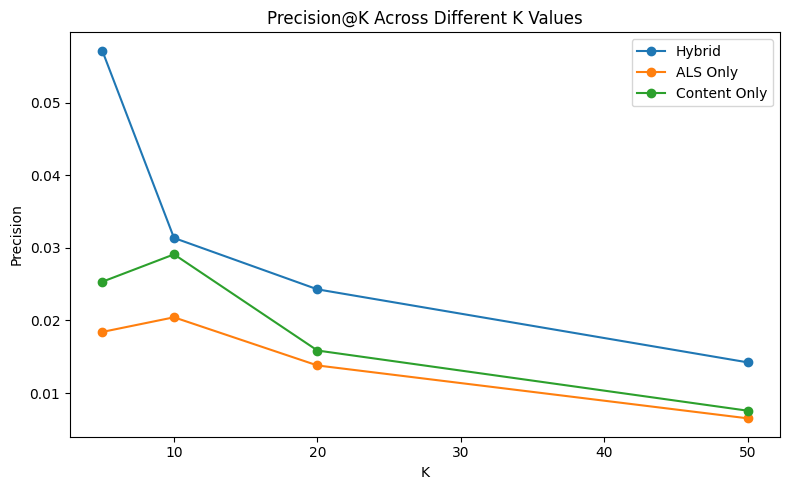

In [ ]:
# ------------------------------------------------------------
# 11. PLOT PRECISION@K ACROSS DIFFERENT CUT-OFF VALUES
# ------------------------------------------------------------

# Create a line chart to compare how Precision@K changes as the
# recommendation list length increases for each model.
figg, ax = plt.subplots(figsize=(8, 5))

# Plot the hybrid model Precision@K values across the selected K values.
ax.plot(Ks, precisions_hybrid, marker="o", label="Hybrid")

# Plot the ALS-only model Precision@K values across the selected K values.
ax.plot(Ks, precisions_als, marker="o", label="ALS Only")

# Plot the content-only model Precision@K values across the selected K values.
ax.plot(Ks, precisions_content, marker="o", label="Content Only")

# Add a descriptive title and axis labels to clarify the comparison.
ax.set_title("Precision@K Across Different K Values")
ax.set_xlabel("K")
ax.set_ylabel("Precision")

# Display the legend so that each model curve can be identified clearly.
ax.legend()

# Adjust spacing so that labels and plot elements fit neatly.
plt.tight_layout()

# Save the figure to the configured output directory, then display it.
save_fig(figg, "precision_curve.png")
plt.show()